<a href="https://colab.research.google.com/github/1Kunalvats9/py-torch/blob/main/CNN_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as f
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [3]:
#converting image files into tensor of 4 dimensions (# number of images, height, width, color_channel)

transform = transforms.Compose([
    transforms.ToTensor(),
])

In [4]:
#Train data
train_data = datasets.MNIST(root='/cnn_data', train=True, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.97MB/s]


In [5]:
test_data = datasets.MNIST(root='/cnn_data', train=False, transform=transform, download=True)

In [12]:
ls

MNIST/


#Creating a Loader

In [13]:
#Creating small batch size for images

train_loader = DataLoader(dataset=train_data,batch_size=10, shuffle=True)
test_loader = DataLoader(dataset=test_data,batch_size=10, shuffle=False)

#Defining CNN Model

In [14]:
conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3)
conv2 = nn.Conv2d(6, 16, 3, 1)

In [15]:
#Grabbing 1 MNIST record/image

for i, (X_train, y_train) in enumerate(train_data):
  break

In [16]:
X_train.shape

torch.Size([1, 28, 28])

In [17]:
x = X_train.view(1, 1, 28, 28) # 1 by 1 by 28 by 28 , 1 batch of 1 image of 28 x 28

In [18]:
#first convolution
x = f.relu(conv1(x))

In [20]:
x.shape # 1 single image, with 6 filters, 26 x 26 is now the image

torch.Size([1, 6, 26, 26])

In [22]:
# pass through the pooling layer
x = f.max_pool2d(x, 2, 2)

x.shape

torch.Size([1, 6, 13, 13])

In [24]:
#Doing second conv layer

x = f.relu(conv2(x))

x.shape

torch.Size([1, 16, 11, 11])

In [25]:
#pooling
x = f.max_pool2d(x, 2, 2)
x.shape

torch.Size([1, 16, 5, 5])

In [ ]:
((((28-2) / 2) -2) / 2) # lost 2 in conv, halved in pooling

#Model Class

In [31]:
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    #CNN ----> conv layers ---> fully connected layers

    #convolutional layers
    self.conv1 = nn.Conv2d(1, 6, 3, 1)
    self.conv2 = nn.Conv2d(6, 16, 3, 1)

    #fully connected layers
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    #first conv layer - changed x to X
    X = f.relu(self.conv1(X))
    X = f.max_pool2d(X, 2, 2)

    #second conv layer - changed x to X
    X = f.relu(self.conv2(X))
    X = f.max_pool2d(X, 2, 2)

    #Re-view to flatten it out for fully connected layers
    X = X.view(-1, 16*5*5)

    # fully connected layer
    X = f.relu(self.fc1(X))
    X = f.relu(self.fc2(X))
    X = self.fc3(X)

    return f.log_softmax(X, dim=1)

In [32]:
#creating instance
torch.manual_seed(41)

model = ConvolutionalNetwork()

model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [33]:
#Loss function optmizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [34]:
start_time = time.time()


#Create variables to track things
epochs = 5
train_losses = []
test_losses = []

train_correct = []
test_correct = []



#For loop for epochs
for i in range(epochs):
  train_corr = 0
  test_corr = 0
  #Train

  for b, (X_train, y_train) in enumerate(train_loader):
    b += 1                             #starting our batches at 1
    y_pred = model(X_train)            #getting predictions
    loss = criterion(y_pred, y_train)  #comapring predictions

    predicted = torch.max(y_pred.data, 1)[1] # adding up the number of correct predictions. Indexed at first point

    batch_corr = (predicted == y_train).sum()  #how many we got correct from this batch
    train_corr += batch_corr #keeping tack as we go along in training

    #update params
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #print some results
    if b%600 == 0:
      print(f"Epoch: {i} Batch: {b} Loss: {loss.item()}")

  train_losses.append(loss)
  train_correct.append(train_corr)


  #Test
  with torch.no_grad(): # so we dont update weights and biases with test data
    for b, (X_test, y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1] #addint up correct predictions

      test_corr += (predicted== y_test).sum()
  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(test_corr)



end_time = time.time()

total = end_time - start_time
print(f"Training took: {total / 60} mins")

Epoch: 0 Batch: 600 Loss: 0.1623610556125641
Epoch: 0 Batch: 1200 Loss: 0.1502392590045929
Epoch: 0 Batch: 1800 Loss: 0.4744560718536377
Epoch: 0 Batch: 2400 Loss: 0.14238706231117249
Epoch: 0 Batch: 3000 Loss: 0.007758188061416149
Epoch: 0 Batch: 3600 Loss: 0.3836284875869751
Epoch: 0 Batch: 4200 Loss: 0.0038223876617848873
Epoch: 0 Batch: 4800 Loss: 0.0021286322735249996
Epoch: 0 Batch: 5400 Loss: 0.0569545142352581
Epoch: 0 Batch: 6000 Loss: 0.00038789428072050214
Epoch: 1 Batch: 600 Loss: 0.005851339548826218
Epoch: 1 Batch: 1200 Loss: 0.3855525553226471
Epoch: 1 Batch: 1800 Loss: 0.004819948226213455
Epoch: 1 Batch: 2400 Loss: 0.003216963727027178
Epoch: 1 Batch: 3000 Loss: 0.0332382395863533
Epoch: 1 Batch: 3600 Loss: 0.5372857451438904
Epoch: 1 Batch: 4200 Loss: 0.04561494290828705
Epoch: 1 Batch: 4800 Loss: 0.0007510822033509612
Epoch: 1 Batch: 5400 Loss: 0.0001173773780465126
Epoch: 1 Batch: 6000 Loss: 0.14201366901397705
Epoch: 2 Batch: 600 Loss: 0.023733172565698624
Epoch: 2

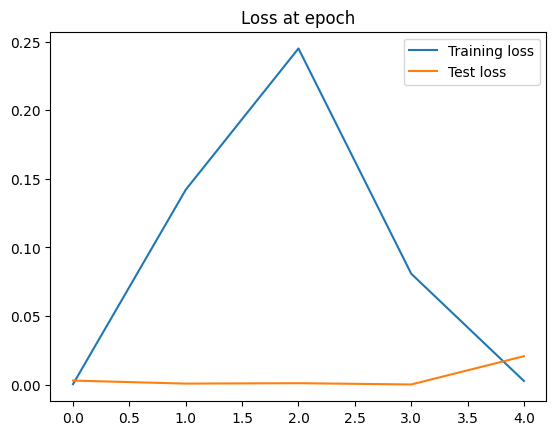

In [35]:
#Plotting graph of losses at each epoch
train_losses = [tl.item() for tl in train_losses]

plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Test loss')
plt.title("Loss at epoch")
plt.legend()

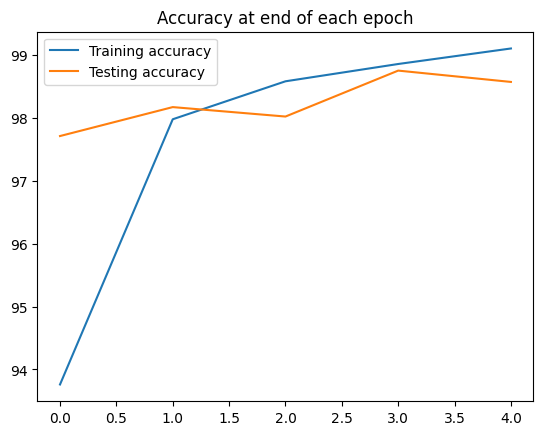

In [36]:
#plotting graph of accuracy at end of each epoch

plt.plot([t/600 for t in train_correct], label='Training accuracy')
plt.plot([t/100 for t in test_correct], label='Testing accuracy')

plt.title('Accuracy at end of each epoch')
plt.legend()

In [37]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [38]:
with torch.no_grad():
  correct = 0
  for X_test, y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val, 1)[1]

    correct += (predicted == y_test).sum()


In [39]:
#Did for correct
correct.item()/len(test_data)

0.9857